<a href="https://colab.research.google.com/github/harshitschooled/AI-ML-Internship/blob/main/Day_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Summary Statistics:
              crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis       

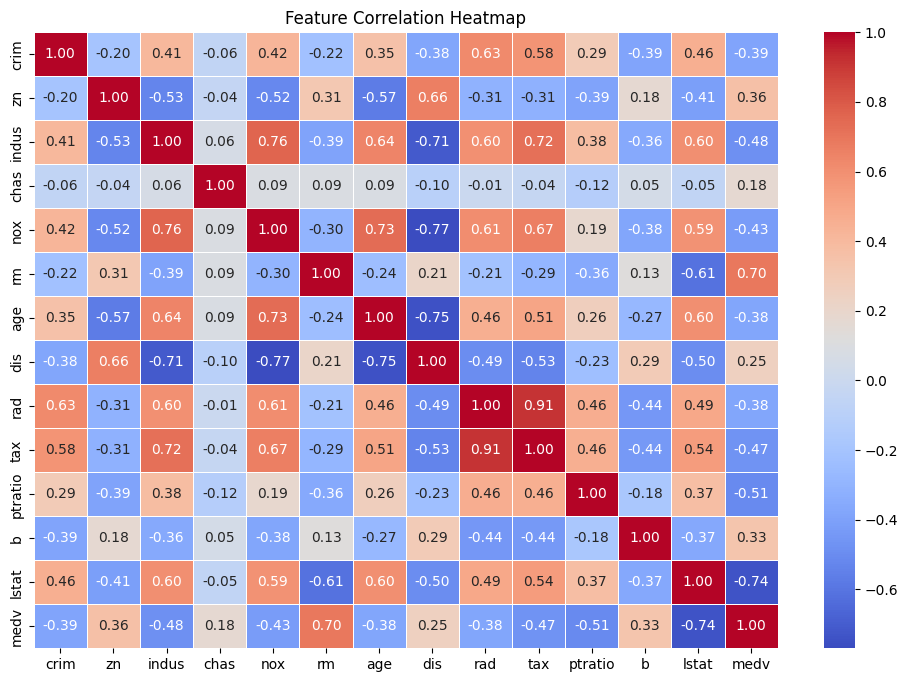

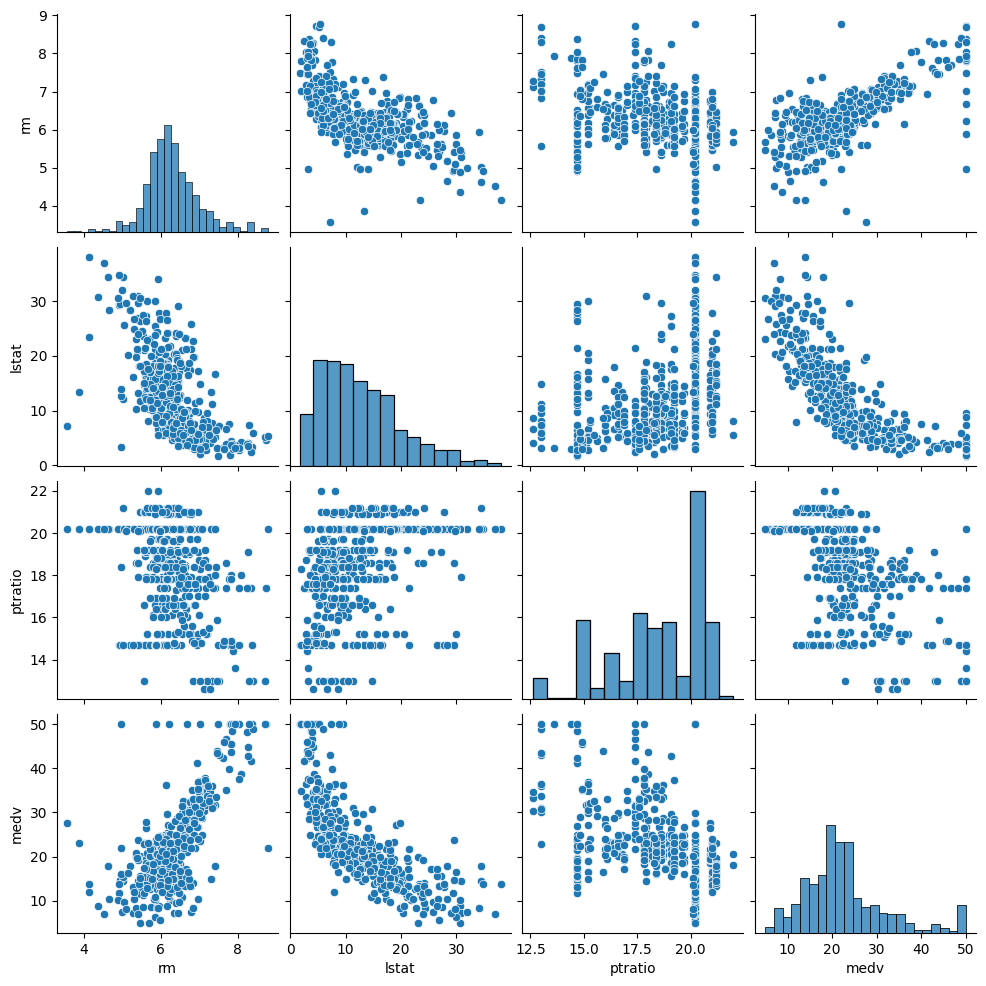

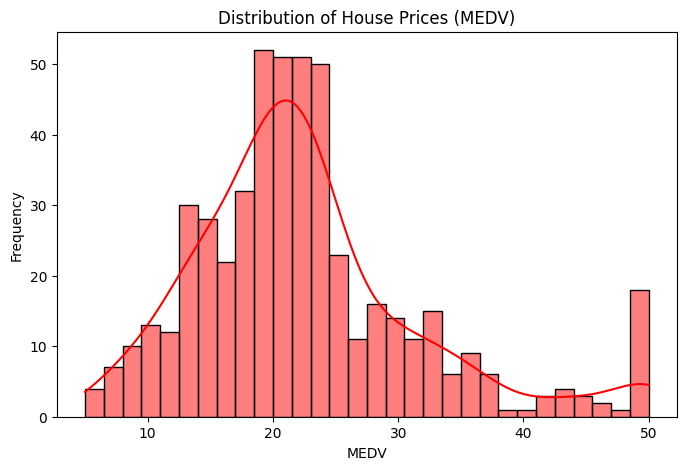

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/boston.csv")
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['medv'], bins=30, kde=True, color='red')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Modelfrom sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286
R² Score: 0.6688
RMSE: 4.9286


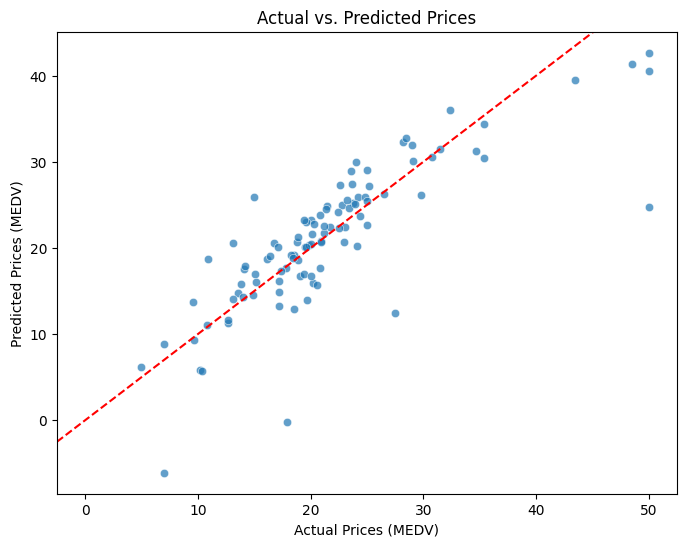

In [71]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices (MEDV)")
plt.title("Actual vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [72]:
from scipy.stats import skew

In [73]:
skewness=df.skew


In [74]:
num_cols = len(df.columns)
plt.figure(figsize=(15, num_cols * 5))

<Figure size 1500x7000 with 0 Axes>

<Figure size 1500x7000 with 0 Axes>

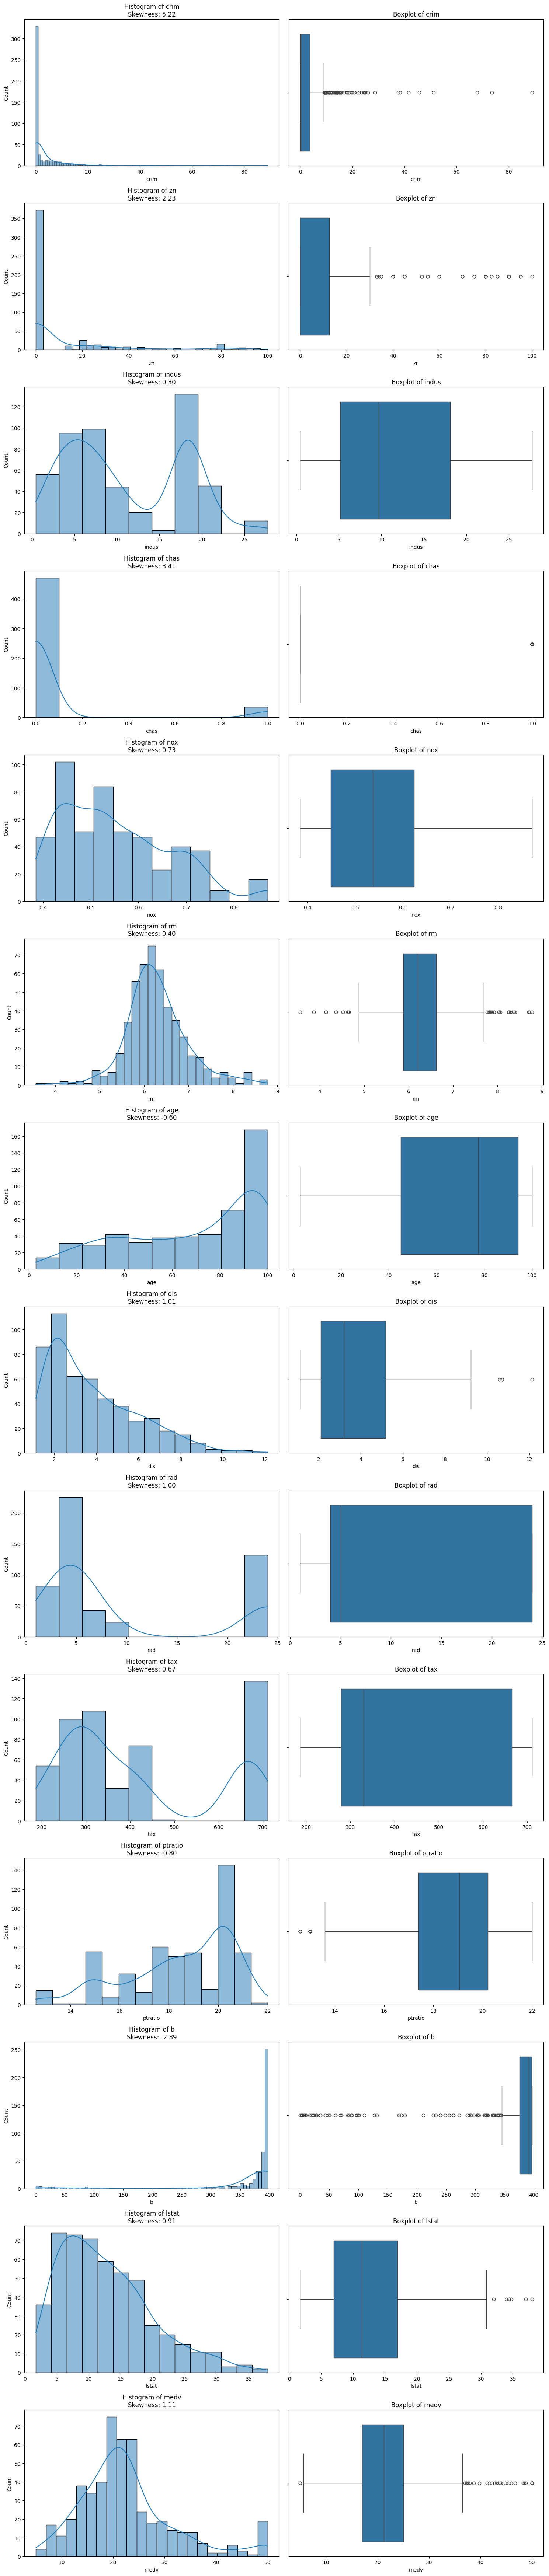

In [75]:
skewness = df.skew()
num_cols = len(df.columns)
num_rows = num_cols # Each column gets one row with a hist and a boxplot

# Create figure and a grid of subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(15, num_rows * 5))

# Iterate through each column to plot its distribution
for i, col in enumerate(df.columns):
    # Histogram for the current column
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')
    axes[i, 0].set_xlabel(col) # Set x-label to column name for clarity

    # Boxplot for the current column
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col) # Set x-label to column name for clarity

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plots

In [76]:
df.skew()

,0
crim,5.223149
zn,2.225666
indus,0.295022
chas,3.405904
nox,0.729308
rm,0.403612
age,-0.598963
dis,1.011781
rad,1.004815
tax,0.669956


In [77]:
import numpy as np
skewed_cols = df.skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index
print("Negatively skewed columns:\n",negatively_skewed)
print("Highly Skewed Columns:\n",highly_skewed)

Negatively skewed columns:
 Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat'], dtype='object')
Highly Skewed Columns:
 Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')


In [78]:
df[highly_skewed]=df[highly_skewed].apply(lambda x: np.log1p(x))

In [79]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [80]:
df[highly_skewed]

,crim,zn,chas,dis,rad,b,medv
0,0.006300,2.944439,0.0,1.627278,0.693147,5.986201,3.218876
1,0.026944,0.000000,0.0,1.786261,1.098612,5.986201,3.117950
2,0.026924,0.000000,0.0,1.786261,1.098612,5.975919,3.575151
3,0.031857,0.000000,0.0,1.954757,1.386294,5.980479,3.538057
4,0.066770,0.000000,0.0,1.954757,1.386294,5.986201,3.616309
...,...,...,...,...,...,...,...
501,0.060747,0.000000,0.0,1.246630,0.693147,5.973784,3.152736
502,0.044275,0.000000,0.0,1.190127,0.693147,5.986201,3.072693
503,0.058986,0.000000,0.0,1.152943,0.693147,5.986201,3.214868
504,0.103991,0.000000,0.0,1.220505,0.693147,5.977492,3.135494


In [81]:
df.skew()

,0
crim,1.269201
zn,1.193451
indus,-0.104641
chas,3.405904
nox,0.098431
rm,0.023275
age,-0.417736
dis,0.331561
rad,0.532760
tax,0.079613


In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7555
RMSE: 0.1842


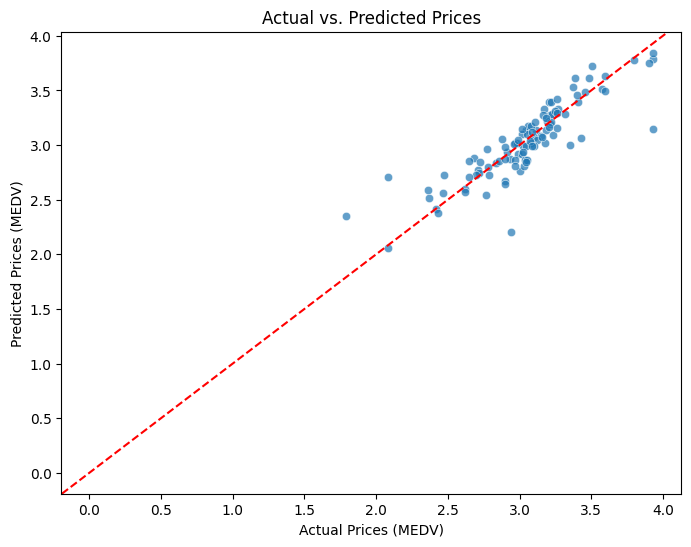

In [83]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices (MEDV)")
plt.title("Actual vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [87]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
r2=r2_score(y_test,y_pred_rf)
rmse=mean_squared_error(y_test,y_pred_rf)**0.5

print(f" Random Forest R² Score: {r2:.4f}")
print(f"Random Forest RMSE: {rmse:.4f}")

 Random Forest R² Score: 0.8409
Random Forest RMSE: 0.1485
